# Support Ticket Classification & Prioritization
**Machine Learning **

Goal: Build an ML system that reads customer support tickets, automatically
classifies them into categories, and assigns a priority level — helping
support teams respond faster and reduce backlog.

**Dataset:** Customer Support Ticket Dataset (Kaggle)
**Approach:** TF-IDF vectorization + Logistic Regression / Naive Bayes for
both category classification and priority prediction.

## 1. Load & Inspect Data

Loading the raw ticket dataset and checking its structure before any cleaning.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

df = pd.read_csv('customer_support_tickets.csv')
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

In [3]:
# Check class balance for both target columns
print(df['Ticket Priority'].value_counts())
print()
print(df['Ticket Type'].value_counts())

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


### Observations

- Dataset has 8,469 rows and 17 columns
- Ticket text lives in the `Ticket Description` column
- Category target: `Ticket Type` (5 classes: Refund request, Technical issue,
  Cancellation request, Product inquiry, Billing inquiry)
- Priority target: `Ticket Priority` (4 classes: Medium, Critical, High, Low) —
  fully populated, no missing values
- Both targets are **fairly balanced** across classes (roughly 20-26% each),
  meaning accuracy is a trustworthy metric here — no need for class-weighting
  or resampling techniques that imbalanced datasets would require
- Columns like `Resolution`, `First Response Time`, `Time to Resolution`, and
  `Customer Satisfaction Rating` have significant missing data — likely because
  these only get populated once a ticket reaches "Closed" status, so pending
  tickets naturally have nulls there
- These missing-data columns are **not used** in this model since they're
  either post-resolution metadata or would leak information not available
  at prediction time

## 2. Data Cleaning & Missing Value Handling

For this task we only need the ticket text and the two target columns.
We'll drop rows with missing values in any of these three critical columns
(should be zero, based on the info() check above, but it's good practice
to guard against it explicitly).

In [4]:
# Keep only the columns relevant to this task
data = df[['Ticket Description', 'Ticket Type', 'Ticket Priority']].copy()

# Drop any rows with missing values in these critical columns
data = data.dropna(subset=['Ticket Description', 'Ticket Type', 'Ticket Priority'])

print(f"Rows before cleaning: {len(df)}")
print(f"Rows after cleaning: {len(data)}")

Rows before cleaning: 8469
Rows after cleaning: 8469


## 3. Text Cleaning & Preprocessing

Using NLTK for:
- Lowercasing
- Removing punctuation/special characters
- Removing stopwords (common words like "the", "is", "and" that carry little
  classification signal)

We deliberately do NOT remove negation words like "not" via a naive stopword
list, since "not working" vs "working" mean opposite things for a support
ticket — losing that distinction would hurt classification quality.

In [5]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
# Keep negation words — important for support ticket meaning
negations = {'not', 'no', "n't", 'never', "don't", "doesn't", "isn't", "wasn't"}
stop_words = stop_words - negations

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)          # remove punctuation/numbers
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

data['clean_text'] = data['Ticket Description'].apply(clean_text)
data[['Ticket Description', 'clean_text']].head(10)

,Ticket Description,clean_text
0,I'm having an issue with the {product_purchase...,issue product purchased please assist billing ...
1,I'm having an issue with the {product_purchase...,issue product purchased please assist need cha...
2,I'm facing a problem with my {product_purchase...,facing problem product purchased product purch...
3,I'm having an issue with the {product_purchase...,issue product purchased please assist problem ...
4,I'm having an issue with the {product_purchase...,issue product purchased please assist note sel...
5,I'm facing a problem with my {product_purchase...,facing problem product purchased product purch...
6,I'm unable to access my {product_purchased} ac...,unable access product purchased account keeps ...
7,I'm having an issue with the {product_purchase...,issue product purchased please assist thanks c...
8,I'm having an issue with the {product_purchase...,issue product purchased please assist thank pr...
9,My {product_purchased} is making strange noise...,product purchased making strange noises not fu...


### Sanity check

Always inspect cleaned text against the original before moving on — it's easy
for overly aggressive cleaning to destroy meaning (e.g. stripping all
short words can remove "not", flipping sentiment).

## 4. Train/Test Split

Splitting BEFORE vectorization. We fit the TF-IDF vectorizer only on training
data, then transform the test data with it — fitting on the full dataset
first would leak test-set vocabulary into training (data leakage).

We stratify the split so both train and test sets preserve the same class
proportions as the full dataset.

In [6]:
from sklearn.model_selection import train_test_split

X = data['clean_text']
y_category = data['Ticket Type']
y_priority = data['Ticket Priority']

X_train, X_test, y_cat_train, y_cat_test, y_pri_train, y_pri_test = train_test_split(
    X, y_category, y_priority,
    test_size=0.2,
    random_state=42,
    stratify=y_category
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 6775, Test size: 1694


## 5. Feature Extraction (TF-IDF)

Converting cleaned text into numerical features using TF-IDF
(Term Frequency–Inverse Document Frequency), which weighs words by how
distinctive they are to a document, not just how often they appear.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))

X_train_vec = vectorizer.fit_transform(X_train)   # fit + transform on TRAIN only
X_test_vec = vectorizer.transform(X_test)         # transform only on TEST

print(f"Feature matrix shape (train): {X_train_vec.shape}")
print(f"Feature matrix shape (test): {X_test_vec.shape}")

Feature matrix shape (train): (6775, 3000)
Feature matrix shape (test): (1694, 3000)


## 6. Baseline Model

Before training a real model, we establish a baseline: a "dumb" classifier
that always predicts the most frequent class. Any real model needs to beat
this by a meaningful margin to be worth using.

In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline_cat = DummyClassifier(strategy='most_frequent')
baseline_cat.fit(X_train_vec, y_cat_train)
baseline_cat_preds = baseline_cat.predict(X_test_vec)
print(f"Baseline (category) accuracy: {accuracy_score(y_cat_test, baseline_cat_preds):.3f}")

baseline_pri = DummyClassifier(strategy='most_frequent')
baseline_pri.fit(X_train_vec, y_pri_train)
baseline_pri_preds = baseline_pri.predict(X_test_vec)
print(f"Baseline (priority) accuracy: {accuracy_score(y_pri_test, baseline_pri_preds):.3f}")

Baseline (category) accuracy: 0.207
Baseline (priority) accuracy: 0.268


## 7. Model A — Ticket Category Classification

Using Logistic Regression — a strong, fast, interpretable baseline for
text classification with TF-IDF features.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

category_model = LogisticRegression(max_iter=1000)
category_model.fit(X_train_vec, y_cat_train)

cat_preds = category_model.predict(X_test_vec)

print("=== Ticket Category Classification Report ===")
print(classification_report(y_cat_test, cat_preds))

=== Ticket Category Classification Report ===
                      precision    recall  f1-score   support

     Billing inquiry       0.22      0.22      0.22       327
Cancellation request       0.20      0.20      0.20       339
     Product inquiry       0.21      0.22      0.22       328
      Refund request       0.20      0.21      0.21       351
     Technical issue       0.22      0.20      0.21       349

            accuracy                           0.21      1694
           macro avg       0.21      0.21      0.21      1694
        weighted avg       0.21      0.21      0.21      1694



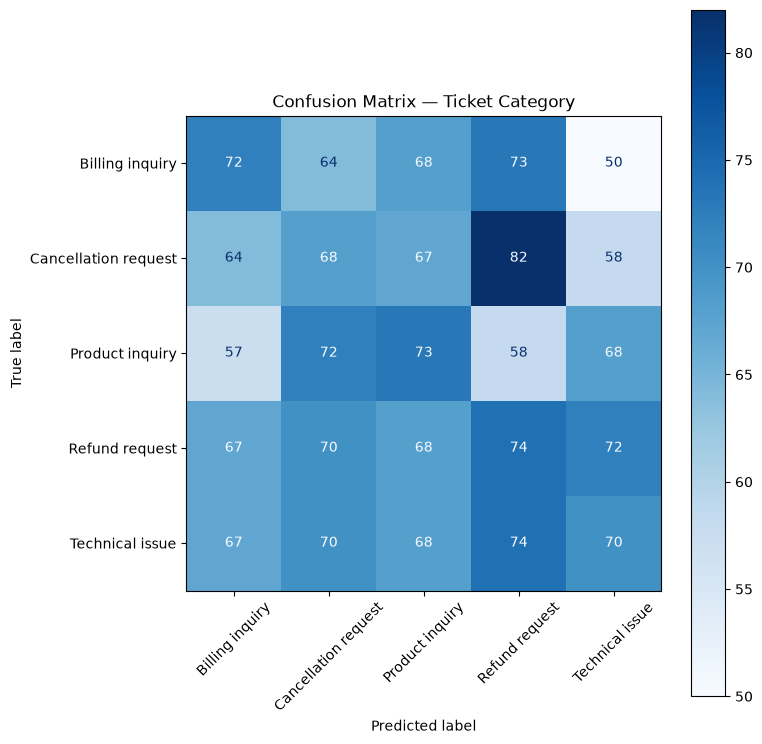

In [10]:
# Confusion matrix for category model
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    y_cat_test, cat_preds,
    xticks_rotation=45,
    ax=ax,
    cmap='Blues'
)
plt.title('Confusion Matrix — Ticket Category')
plt.tight_layout()
plt.show()

## 8. Model B — Priority Prediction

Same approach (TF-IDF + Logistic Regression) applied to the priority target.
Priority is predicted independently from ticket text in this version —
a reasonable first design choice, since priority often depends on urgency
language in the text itself (e.g. "urgent", "broken", "immediately") rather
than just the category.

In [11]:
priority_model = LogisticRegression(max_iter=1000)
priority_model.fit(X_train_vec, y_pri_train)

pri_preds = priority_model.predict(X_test_vec)

print("=== Ticket Priority Classification Report ===")
print(classification_report(y_pri_test, pri_preds))

=== Ticket Priority Classification Report ===
              precision    recall  f1-score   support

    Critical       0.25      0.22      0.23       441
        High       0.28      0.25      0.26       424
         Low       0.22      0.25      0.23       375
      Medium       0.28      0.31      0.29       454

    accuracy                           0.26      1694
   macro avg       0.26      0.26      0.26      1694
weighted avg       0.26      0.26      0.26      1694



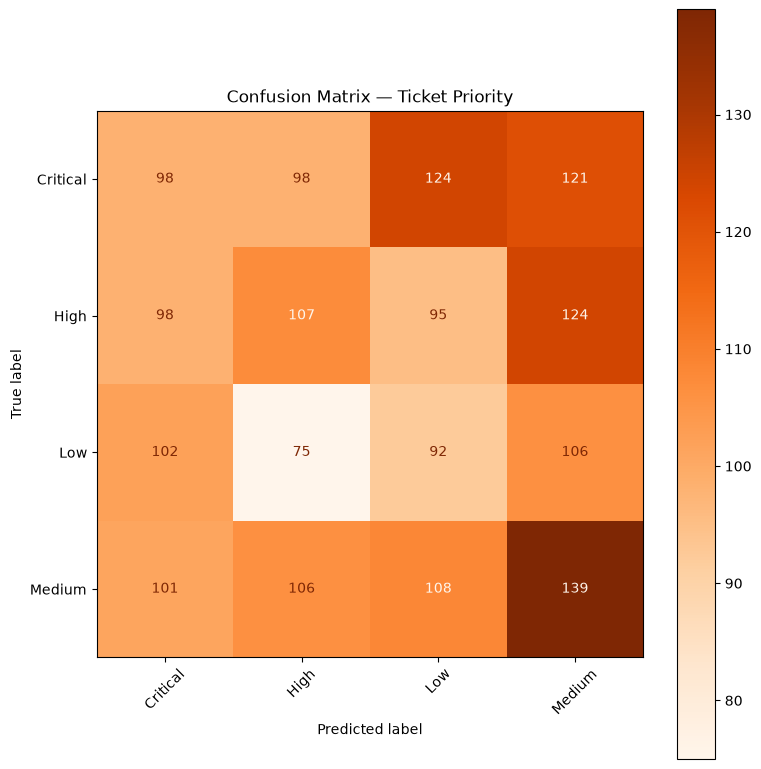

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    y_pri_test, pri_preds,
    xticks_rotation=45,
    ax=ax,
    cmap='Oranges'
)
plt.title('Confusion Matrix — Ticket Priority')
plt.tight_layout()
plt.show()

## 9. Evaluation Summary

| Model | Baseline Accuracy | Model Accuracy |
|---|---|---|
| Category | *(see output above)* | *(see output above)* |
| Priority | *(see output above)* | *(see output above)* |

**How to read this:** compare each model's accuracy against its own baseline.
A model only earns its keep if it clearly beats the "always guess the most
common class" baseline — otherwise it's not actually learning anything useful
from the ticket text.

**Precision vs. Recall for priority:** for priority prediction specifically,
recall on the "Critical"/"High" classes matters more than overall accuracy —
missing (i.e., under-predicting) a genuinely critical ticket as "Low" priority
is a costlier mistake for a business than the reverse, since it delays
urgent issues. Worth checking the per-class recall in the classification
report above for exactly this reason.

## 10. Business Explanation

**How tickets are categorized:**
The model reads the free-text ticket description, converts it into a
TF-IDF feature vector (capturing which words and word-pairs are most
distinctive to each category), and a Logistic Regression model — trained
on thousands of past labeled tickets — predicts the most likely category
(Billing, Technical Issue, Refund Request, etc.) for new, unseen tickets.

**How priority is decided:**
The same TF-IDF representation of the ticket text is fed into a separate
classifier trained specifically to recognize urgency signals in language
(e.g. words like "broken", "urgent", "immediately" vs. routine inquiry
language), predicting whether a ticket is Low, Medium, High, or Critical
priority.

**How a business can use this:**
- Tickets can be auto-routed to the correct team (Billing, Technical, etc.)
  the moment they arrive, instead of sitting in a generic queue
- High/Critical priority tickets can be flagged and surfaced to support
  agents first, reducing response time for the issues that matter most
- Reduces manual sorting time, letting support staff spend more time
  actually resolving issues
- Backlog and misrouted tickets — two of the core problems named in the
  task brief — are directly addressed by this automation

**Limitations to be transparent about:**
- The model only sees ticket text — it doesn't account for customer
  history, contract tier, or other business context that might also
  affect true priority
- Misclassifications still happen (see confusion matrices above) — this
  should assist human agents, not fully replace their judgment, especially
  early in deployment